<a href="https://colab.research.google.com/github/sachumonpsajeev-cyber/Physiological-Signal-Based-Stress-Prediction/blob/main/sachu_datamining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import io
from google.colab import files
uploaded =files.upload()

Saving St87014Auto-mpg dataset (1).csv to St87014Auto-mpg dataset (1).csv


In [ ]:
import pandas as pd
import io
from google.colab import files

uploaded = files.upload()

# Get the actual key from the uploaded dictionary
actual_key = list(uploaded.keys())[0]

# Use the actual key to access the file content
df = pd.read_csv(io.BytesIO(uploaded[actual_key]))

# Print the actual key for verification
print(f"Actual key: {actual_key}")

Saving St87014Auto-mpg dataset (1).csv to St87014Auto-mpg dataset (1) (1).csv
Actual key: St87014Auto-mpg dataset (1) (1).csv


Categorical and Continuous Variable Identification

In [ ]:
import pandas as pd
import io
from google.colab import files

# Upload the file
uploaded = files.upload()

# Get the actual key from the uploaded dictionary
actual_key = list(uploaded.keys())[0]

# Use the actual key to access the file content
df = pd.read_csv(io.BytesIO(uploaded[actual_key]))
# The line above now uses 'actual_key' instead of a hardcoded filename

# Print the actual key for verification
print(f"Actual key: {actual_key}")

# Get a list of all columns in the DataFrame
all_columns = df.columns.tolist()

# Identify numerical columns
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()

# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Print the results
print("Categorical Variables:", categorical_columns)
print("Continuous Variables:", numerical_columns)

Saving St87014Auto-mpg dataset (1).csv to St87014Auto-mpg dataset (1) (2).csv
Actual key: St87014Auto-mpg dataset (1) (2).csv
Categorical Variables: ['horsepower', 'Car model']
Continuous Variables: ['mpg', 'cylinders', 'displacement', 'weight', 'acceleration', 'model year', 'origin']


Descriptive Statistics for Continuous Variables

In [ ]:
# Descriptive statistics (as shown in Table 2)
print(df[numerical_columns].describe())

# Analyze standard deviation (as in the report)
descriptive_stats = df[numerical_columns].describe().T  # Transpose for easier analysis

for col in numerical_columns: # Iterate through numerical_columns
    std = descriptive_stats.loc[col]['std']
    mean = descriptive_stats.loc[col]['mean']
    min_val = descriptive_stats.loc[col]['min']
    max_val = descriptive_stats.loc[col]['max']

    print(f"\n--- {col} ---")
    print(f"  Range: {min_val} to {max_val}")
    print(f"  Mean: {mean:.2f}, Std Dev: {std:.2f}")

    if std > mean / 2:  # Simple rule of thumb for "high" std
        print("  High standard deviation: Data is more spread out.")
    else:
        print("  Low standard deviation: Data is clustered around the mean.")

             mpg  cylinders  displacement       weight  acceleration  \
count  54.000000  54.000000     54.000000    54.000000     54.000000   
mean   24.833333   5.203704    174.592593  2763.611111     15.835185   
std     7.500239   1.686569    105.662960   772.712972      3.391730   
min    11.000000   3.000000     70.000000  1835.000000      8.500000   
25%    18.000000   4.000000     97.000000  2137.500000     14.000000   
50%    26.000000   4.000000    121.000000  2523.500000     15.650000   
75%    30.000000   6.000000    231.750000  3278.500000     18.000000   
max    44.000000   8.000000    454.000000  4657.000000     24.800000   

       model year     origin  
count   54.000000  54.000000  
mean    76.166667   1.740741  
std      3.800447   0.805293  
min     70.000000   1.000000  
25%     73.000000   1.000000  
50%     76.000000   2.000000  
75%     79.000000   2.000000  
max     82.000000   3.000000  

--- mpg ---
  Range: 11.0 to 44.0
  Mean: 24.83, Std Dev: 7.50
  Low st

# Analyzing Skewness

In [ ]:
for col in numerical_columns:
    mean = df[col].mean()
    median = df[col].median()

    print(f"\n--- {col} ---")
    print(f"  Mean: {mean:.2f}, Median: {median:.2f}")

    if abs(mean - median) < 0.1 * mean:  # Threshold for "close" - adjust as needed
        print("  Symmetrically distributed")
    elif mean > median:
        print("  Positively skewed (right-skewed)")
    else:
        print("  Negatively skewed (left-skewed)")


--- mpg ---
  Mean: 24.83, Median: 26.00
  Symmetrically distributed

--- cylinders ---
  Mean: 5.20, Median: 4.00
  Positively skewed (right-skewed)

--- displacement ---
  Mean: 174.59, Median: 121.00
  Positively skewed (right-skewed)

--- weight ---
  Mean: 2763.61, Median: 2523.50
  Symmetrically distributed

--- acceleration ---
  Mean: 15.84, Median: 15.65
  Symmetrically distributed

--- model year ---
  Mean: 76.17, Median: 76.00
  Symmetrically distributed

--- origin ---
  Mean: 1.74, Median: 2.00
  Negatively skewed (left-skewed)


# Descriptive Statistics for Categorical Variables

In [ ]:
for col in numerical_columns:
    print(f"\n--- {col} ---")
    print(df[col].describe())

    # Get value counts (similar to Table 6 and analysis of car models)
    print("\nValue Counts:")
    print(df[col].value_counts().head(10))  # Top 10 values


--- mpg ---
count    54.000000
mean     24.833333
std       7.500239
min      11.000000
25%      18.000000
50%      26.000000
75%      30.000000
max      44.000000
Name: mpg, dtype: float64

Value Counts:
mpg
26.0    8
18.0    4
14.0    3
25.0    3
15.0    2
30.0    2
13.0    2
31.0    2
21.0    1
20.0    1
Name: count, dtype: int64

--- cylinders ---
count    54.000000
mean      5.203704
std       1.686569
min       3.000000
25%       4.000000
50%       4.000000
75%       6.000000
max       8.000000
Name: cylinders, dtype: float64

Value Counts:
cylinders
4    32
8    12
6     9
3     1
Name: count, dtype: int64

--- displacement ---
count     54.000000
mean     174.592593
std      105.662960
min       70.000000
25%       97.000000
50%      121.000000
75%      231.750000
max      454.000000
Name: displacement, dtype: float64

Value Counts:
displacement
97     8
350    5
98     5
318    2
232    2
79     2
105    2
156    2
113    1
440    1
Name: count, dtype: int64

--- weight ---
c

# Analyzing Specific Categories

In [ ]:
# Example: Analyzing "Plymouth" cars (similar to Table 7)
if 'Car model' in df.columns: #make sure the column exists
  plymouth_df = df[df['Car model'].str.strip() == 'plymouth'] #remove white spaces
  plymouth_counts = plymouth_df['model year'].value_counts().reset_index()
  plymouth_counts.columns = ['model_year', 'count']
  print("\n--- Plymouth Cars by Year ---")
  print(plymouth_counts)

# Example: Analyzing "Datsun" cars (similar to Table 9)
  if 'Car model' in df.columns: #make sure the column exists
    datsun_df = df[df['Car model'].str.strip() == 'datsun']
    print("\n--- Datsun Cars ---")
    print(datsun_df[['model year', 'mpg', 'cylinders', 'displacement', 'horsepower', 'weight']])

# Example: Finding heaviest and lightest cars (similar to Table 9)
  if 'Car model' in df.columns and 'weight' in df.columns: #make sure the column exists
    heaviest_car = df.loc[df['weight'].idxmax()]
    lightest_car = df.loc[df['weight'].idxmin()]
    print("\n--- Heaviest Car ---")
    print(heaviest_car[['Car model', 'weight']])
    print("\n--- Lightest Car ---")
    print(lightest_car[['Car model', 'weight']])

# Example: Finding highest and lowest horsepower cars (similar to Table 10)
  if 'Car model' in df.columns and 'horsepower' in df.columns: #make sure the column exists
    highest_hp_car = df.loc[df['horsepower'].idxmax()]
    lowest_hp_car = df.loc[df['horsepower'].idxmin()]
    print("\n--- Highest Horsepower Car ---")
    print(highest_hp_car[['Car model', 'horsepower']])
    print("\n--- Lowest Horsepower Car ---")
    print(lowest_hp_car[['Car model', 'horsepower']])

# Example: Finding highest and lowest mpg cars (similar to Table 11)
  if 'Car model' in df.columns and 'mpg' in df.columns: #make sure the column exists
    highest_mpg_car = df.loc[df['mpg'].idxmax()]
    lowest_mpg_car = df.loc[df['mpg'].idxmin()]
    print("\n--- Highest MPG Car ---")
    print(highest_mpg_car[['Car model', 'mpg']])
    print("\n--- Lowest MPG Car ---")
    print(lowest_mpg_car[['Car model', 'mpg']])


--- Plymouth Cars by Year ---
   model_year  count
0          70      2

--- Datsun Cars ---
    model year   mpg  cylinders  displacement horsepower  weight
15          74  31.0          4            79         67    1950

--- Heaviest Car ---
Car model    ford 
weight        4657
Name: 21, dtype: object

--- Lightest Car ---
Car model    volkswagen 
weight              1835
Name: 4, dtype: object

--- Highest Horsepower Car ---
Car model     ford 
horsepower        ?
Name: 6, dtype: object

--- Lowest Horsepower Car ---
Car model     amc 
horsepower     100
Name: 7, dtype: object

--- Highest MPG Car ---
Car model     vw 
mpg          44.0
Name: 53, dtype: object

--- Lowest MPG Car ---
Car model    oldsmobile 
mpg                 11.0
Name: 14, dtype: object


# Data Visualization

Bar chart of Car model

Saving St87014Auto-mpg dataset (1).csv to St87014Auto-mpg dataset (1) (5).csv


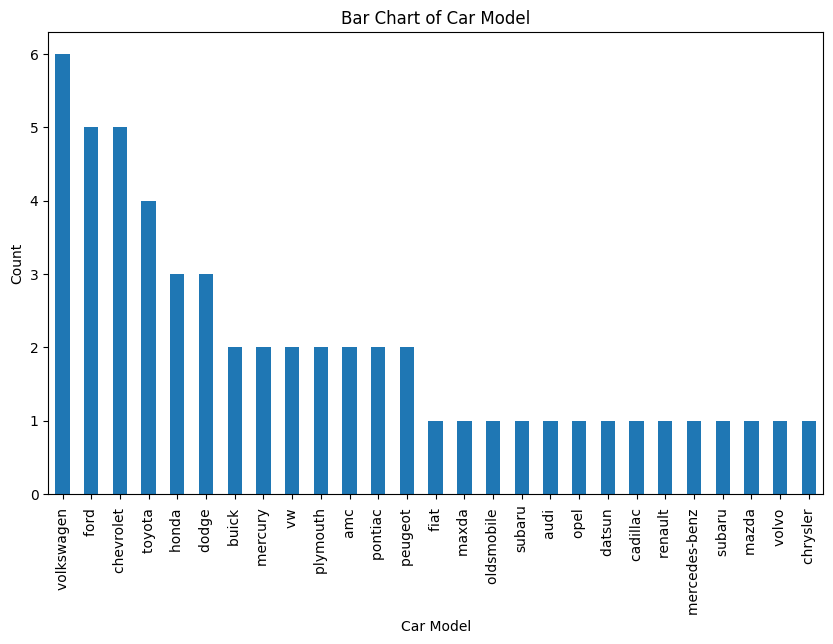

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import io
from google.colab import files
uploaded = files.upload()

# Get the actual key from the uploaded dictionary
actual_key = list(uploaded.keys())[0]  # This line gets the actual key

# Use the actual key to access the file content
df = pd.read_csv(io.BytesIO(uploaded[actual_key]))  # Now using 'actual_key'

# Bar chart of Car model (similar to Table 12)
if 'Car model' in df.columns:  # make sure the column exists
    plt.figure(figsize=(10, 6))
    df['Car model'].value_counts().plot(kind='bar')
    plt.title('Bar Chart of Car Model')
    plt.xlabel('Car Model')
    plt.ylabel('Count')
    plt.show()

# Bar chart of model year

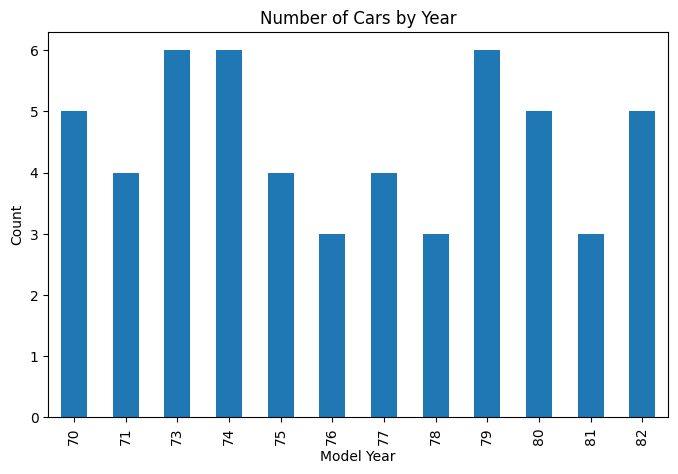

In [ ]:
# Bar chart of model year (similar to Table 13)
if 'model year' in df.columns: #make sure the column exists
  plt.figure(figsize=(8, 5))
  df['model year'].value_counts().sort_index().plot(kind='bar')
  plt.title('Number of Cars by Year')
  plt.xlabel('Model Year')
  plt.ylabel('Count')
  plt.show()

# Box plot of mpg

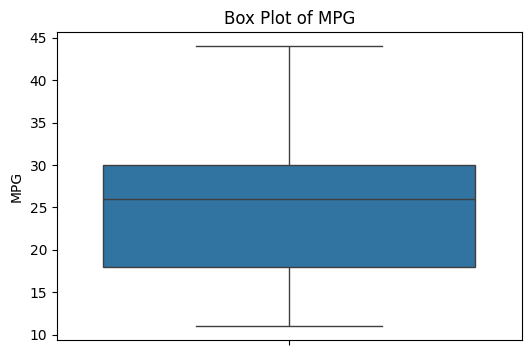

In [ ]:
# Box plot of mpg (similar to Table 17)
if 'mpg' in df.columns: #make sure the column exists
  plt.figure(figsize=(6, 4))
  sns.boxplot(y=df['mpg'])
  plt.title('Box Plot of MPG')
  plt.ylabel('MPG')
  plt.show()

# Histogram of horsepower

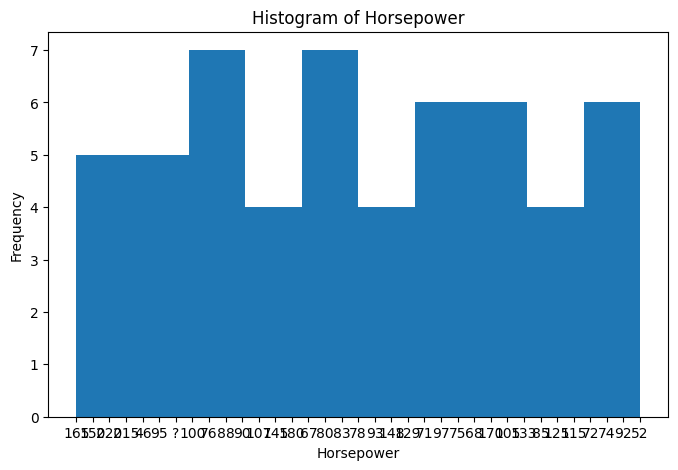

In [ ]:
# Histogram of horsepower (similar to Table 15)
if 'horsepower' in df.columns: #make sure the column exists
  plt.figure(figsize=(8, 5))
  plt.hist(df['horsepower'], bins=10)  # Adjust bins as needed
  plt.title('Histogram of Horsepower')
  plt.xlabel('Horsepower')
  plt.ylabel('Frequency')
  plt.show()

# Box plot of mpg

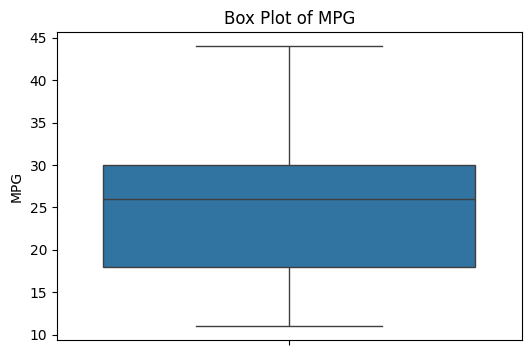

In [ ]:
# Box plot of mpg (similar to Table 17)
if 'mpg' in df.columns: #make sure the column exists
  plt.figure(figsize=(6, 4))
  sns.boxplot(y=df['mpg'])
  plt.title('Box Plot of MPG')
  plt.ylabel('MPG')
  plt.show()

# box plot of displacement

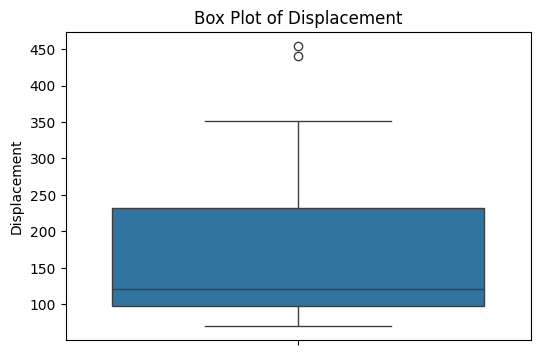

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'data' is your pandas DataFrame
if 'displacement' in df.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df['displacement'])
    plt.title('Box Plot of Displacement')
    plt.ylabel('Displacement')
    plt.show()
else:
    print("Error: 'displacement' column not found in DataFrame.")

# box plot of acceleration

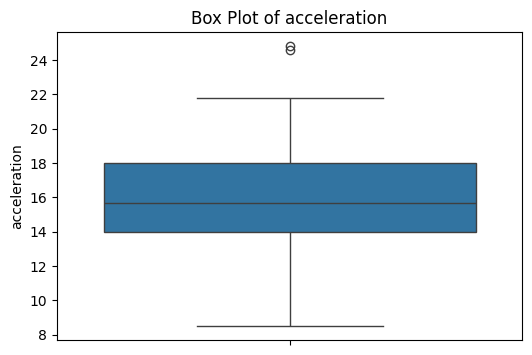

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

if 'acceleration' in df.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df['acceleration'])
    plt.title('Box Plot of acceleration')
    plt.ylabel('acceleration')
    plt.show()
else:
    print("Error: 'acceleration' column not found in DataFrame.")

# line chart for origin

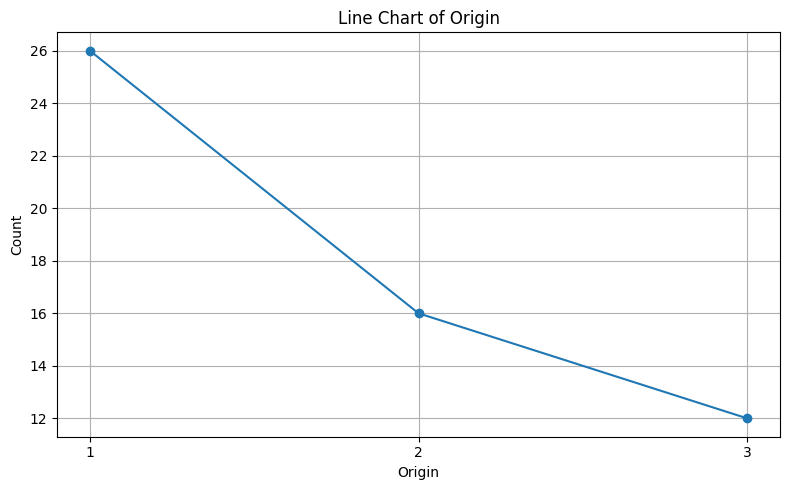

In [ ]:
import matplotlib.pyplot as plt

if 'origin' in df.columns:
    # Calculate the count of each origin
    origin_counts = df['origin'].value_counts().sort_index()  # Sort by origin

    # Create the line chart
    plt.figure(figsize=(8, 5))
    plt.plot(origin_counts.index, origin_counts.values, marker='o')  # 'o' adds markers to the line
    plt.title('Line Chart of Origin')
    plt.xlabel('Origin')
    plt.ylabel('Count')
    plt.xticks(origin_counts.index)  # Ensure all origin values are shown on x-axis
    plt.grid(True)  # Add grid lines for better readability
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'origin' column not found in DataFrame.")

# line chart for weight

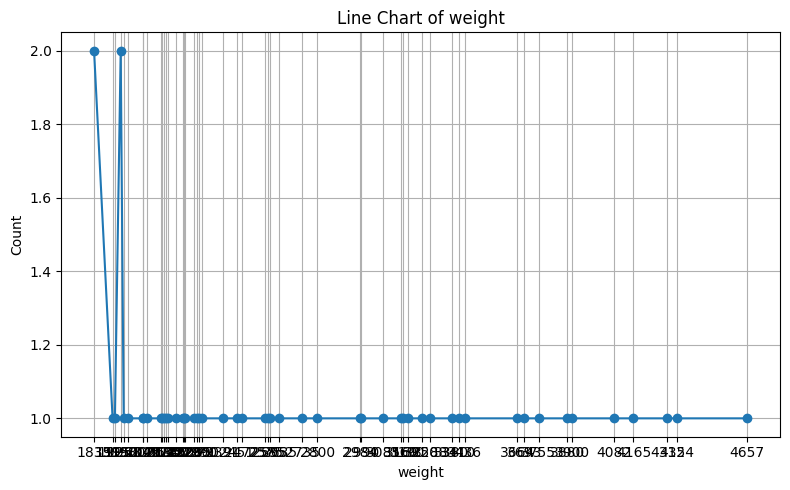

In [ ]:
import matplotlib.pyplot as plt

if 'weight' in df.columns:
    # Calculate the count of each origin
    origin_counts = df['weight'].value_counts().sort_index()  # Sort by origin

    # Create the line chart
    plt.figure(figsize=(8, 5))
    plt.plot(origin_counts.index, origin_counts.values, marker='o')  # 'o' adds markers to the line
    plt.title('Line Chart of weight')
    plt.xlabel('weight')
    plt.ylabel('Count')
    plt.xticks(origin_counts.index)  # Ensure all origin values are shown on x-axis
    plt.grid(True)  # Add grid lines for better readability
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'weight' column not found in DataFrame.")

# line chart for year

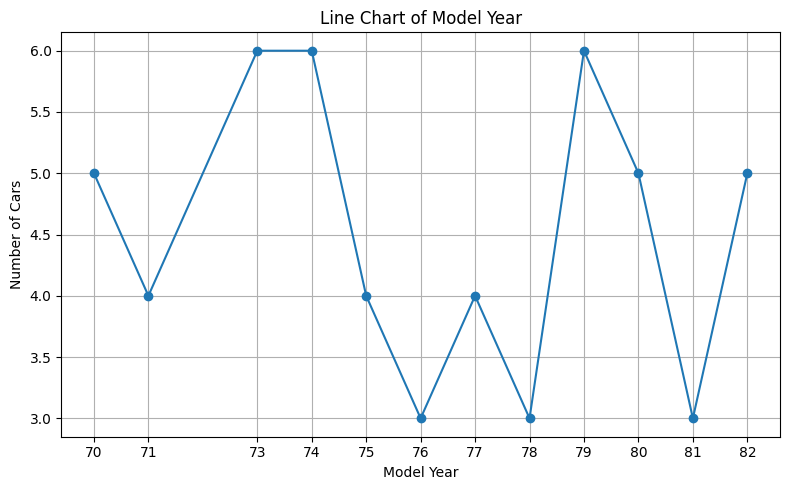

In [ ]:
import matplotlib.pyplot as plt

if 'model year' in df.columns:
    # Calculate the count of cars for each model year
    year_counts = df['model year'].value_counts().sort_index()  # Sort by year

    # Create the line chart
    plt.figure(figsize=(8, 5))
    plt.plot(year_counts.index, year_counts.values, marker='o')  # 'o' adds markers
    plt.title('Line Chart of Model Year')
    plt.xlabel('Model Year')
    plt.ylabel('Number of Cars')
    plt.xticks(year_counts.index)  # Show all years on x-axis
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'model year' column not found in DataFrame.")

# Scatter Plots

# Pair Plots

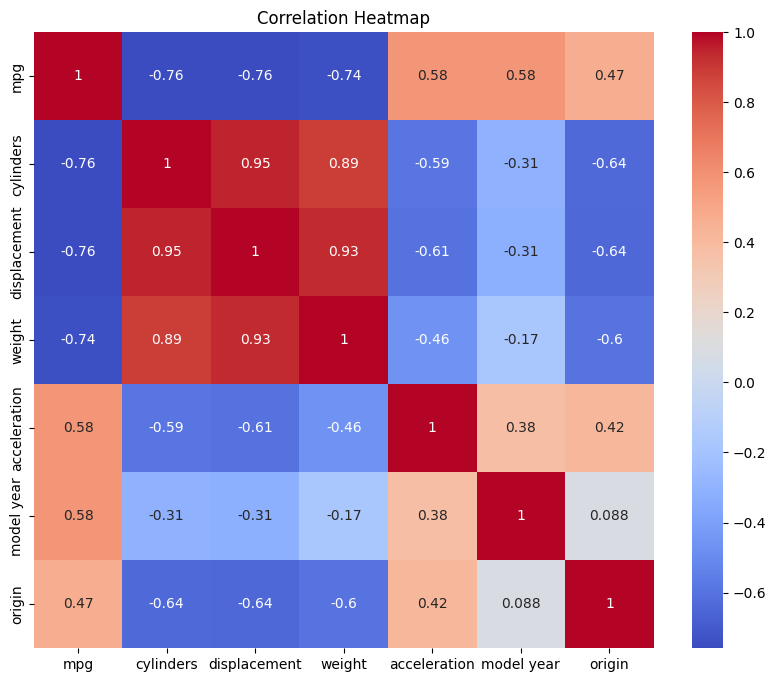

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_correlation_heatmap(df, num_cols):
    """
    Plots a heatmap of the correlation matrix for numerical columns.

    Args:
        df: pandas DataFrame
        num_cols: list of numerical columns
    """
    plot_cols = [col for col in num_cols if col in df.columns] # Filter out columns that don't exist
    if not plot_cols:
      print("No numerical columns found for correlation heatmap.")
      return

    corr_matrix = df[plot_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm') # 'annot=True' displays correlation values
    plt.title('Correlation Heatmap')
    plt.show()

# Example Usage:
numerical_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
plot_correlation_heatmap(df, numerical_cols)

# Outlier Detection (Z-Score)

In [ ]:
import numpy as np
from scipy import stats

# Calculate Z-scores for 'mpg' (similar to Table 18)
if 'mpg' in df.columns: #make sure the column exists
  df['mpg_zscore'] = stats.zscore(df['mpg'])

  # Identify outliers (e.g., Z-score > 3 or < -3)
  outliers = df[(df['mpg_zscore'] > 3) | (df['mpg_zscore'] < -3)]
  print("\n--- MPG Outliers (Z-score) ---")
  print(outliers['mpg_zscore'])


--- MPG Outliers (Z-score) ---
Series([], Name: mpg_zscore, dtype: float64)


# violin plot of MPG

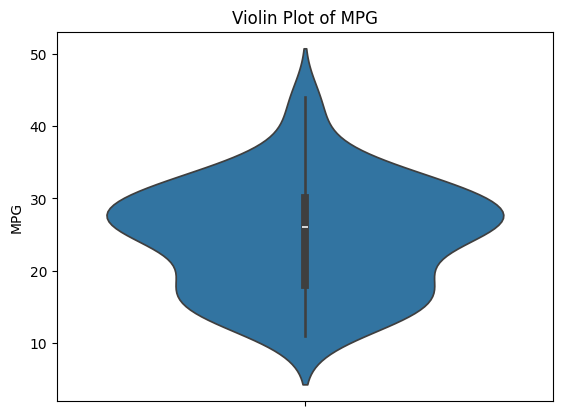

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a violin plot for the 'mpg' variable
sns.violinplot(y=df['mpg'])
plt.title('Violin Plot of MPG')
plt.ylabel('MPG')
plt.show()

#Joint Plot

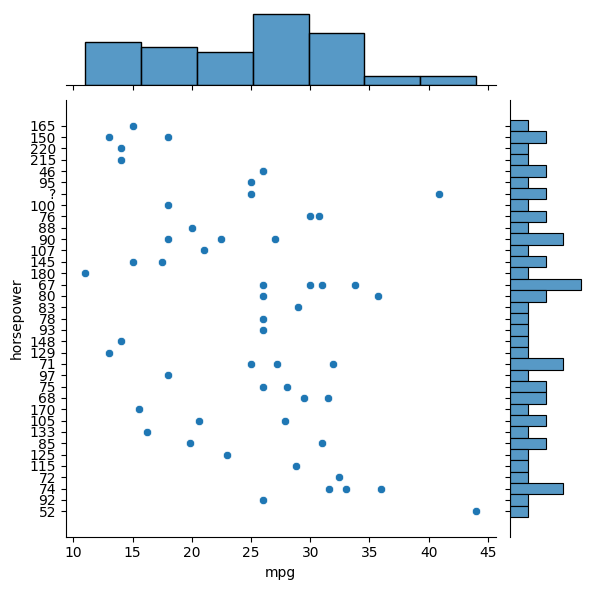

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a joint plot for 'mpg' and 'horsepower'
sns.jointplot(x='mpg', y='horsepower', data=df)
plt.show()

# scatter plot

<Figure size 800x600 with 0 Axes>

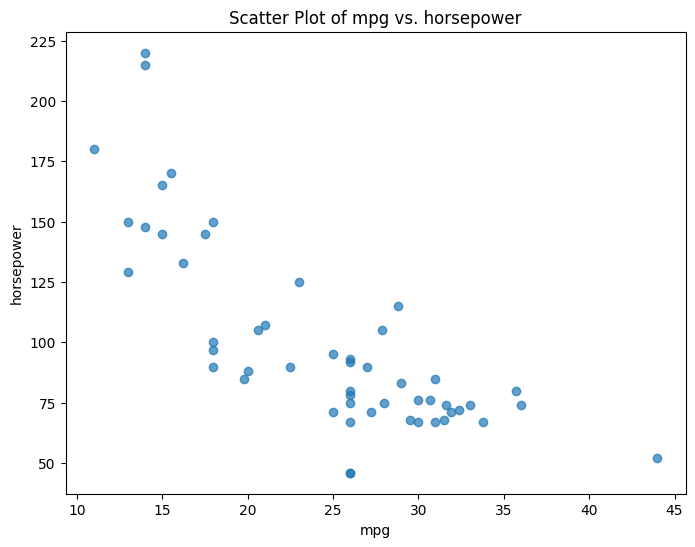

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your pandas DataFrame containing the Auto MPG dataset

# Select the variables for the scatter plot
x_variable = 'mpg'  # Replace with the name of your x-axis variable (e.g., 'horsepower', 'weight')
y_variable = 'horsepower'  # Replace with the name of your y-axis variable (e.g., 'displacement', 'acceleration')

# Create the scatter plot using Matplotlib
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your pandas DataFrame containing the Auto MPG dataset

# Select the variables for the scatter plot
x_variable = 'mpg'  # Replace with the name of your x-axis variable (e.g., 'horsepower', 'weight')
y_variable = 'horsepower'  # Replace with the name of your y-axis variable (e.g., 'displacement', 'acceleration')

# Create the scatter plot using Matplotlib
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
plt.scatter(df[x_variable], df[y_variable], alpha=0.7)  # alpha controls point transparency
plt.title(f'Scatter Plot of {x_variable} vs. {y_variable}')
plt.xlabel(x_variable)
plt.ylabel(y_variable)
plt.show()